# Encoder-free EMF + drifting on conditional MNIST

This notebook adapts the Encoder-Free Drifting report to the six-class MNIST setup used by the other notebooks. It is intentionally not a VAE: the model maps a noisy 28x28 image directly to a clean 28x28 image.

The objective has four branches: Euler Mean Flow (EMF), pixel-space drifting, hidden-feature drifting, and a characteristic-function correction. The three correction branches are capped by gradient norm before being added to the EMF gradient. Late checkpoints are averaged for evaluation.

The model is kept at approximately the same parameter budget as `pretrained-full-joint.ipynb` (~357k parameters), so comparisons isolate the algorithm rather than a larger network.

In [1]:
import math
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader

%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
from src.eval import evaluate_mnist_generation, fit_mnist_evaluator, plot_loss_history

torch.manual_seed(7)
np.random.seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

C:\Users\mateo\Desktop\polymath-jr-drifting
Using: cuda


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor([DIGIT_TO_CLASS[int(digit)] for digit in raw_targets], dtype=torch.long)
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)
BATCH_SIZE = 500
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))

Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
class f(nn.Module):
    """Direct conditional pixel generator with no VAE or pretrained encoder."""
    def __init__(self, input_dim=784, hidden_dim=192, num_classes=6, label_dim=32, time_frequencies=15):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.num_classes = num_classes
        self.label_dim = label_dim
        self.time_frequencies = time_frequencies
        frequencies = 2.0 * math.pi * torch.logspace(0.0, 2.0, time_frequencies)
        self.register_buffer("frequencies", frequencies)
        self.label_embedding = nn.Embedding(num_classes, label_dim)
        time_dim = 4 * time_frequencies
        self.input = nn.Linear(input_dim + time_dim + label_dim, hidden_dim)
        self.hidden = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, input_dim)

    def time_features(self, t, r):
        angles = torch.cat([t.reshape(-1, 1) * self.frequencies, r.reshape(-1, 1) * self.frequencies], dim=1)
        return torch.cat([angles.sin(), angles.cos()], dim=1)

    def forward(self, x_t, t, r, labels, return_features=False):
        x_t = x_t.reshape(x_t.shape[0], -1)
        conditioning = torch.cat([x_t, self.time_features(t, r), self.label_embedding(labels.long())], dim=1)
        hidden = F.leaky_relu(self.input(conditioning), negative_slope=0.2)
        hidden = F.leaky_relu(self.hidden(hidden), negative_slope=0.2)
        clean_prediction = torch.sigmoid(self.output(hidden))
        return (clean_prediction, hidden) if return_features else clean_prediction

    def generate(self, noise, labels, return_features=False):
        zeros = torch.zeros(noise.shape[0], device=noise.device)
        ones = torch.ones(noise.shape[0], device=noise.device)
        return self(noise, zeros, ones, labels, return_features=return_features)

model = f(num_classes=len(SELECTED_DIGITS)).to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
reference_parameter_count = 357_280
print(f"Encoder-free parameters: {parameter_count:,}")
print(f"Reference MNIST model parameters: {reference_parameter_count:,}")
print(f"Relative parameter difference: {abs(parameter_count - reference_parameter_count) / reference_parameter_count:.2%}")

Encoder-free parameters: 356,944
Reference MNIST model parameters: 357,280
Relative parameter difference: 0.09%


In [4]:
# EMF uses the conventional noise-to-data direction: t=0 is noise and t=1 is data.
DELTA_T = 0.001
TIME_DIAGONAL_PROBABILITY = 0.5
DENOMINATOR_FLOOR = 0.1
DRIFT_TEMPERATURES = (0.5, 1.0, 2.0)

def sample_emf_times(batch_size, device):
    t = torch.rand(batch_size, device=device)
    r = t + (1.0 - t) * torch.rand(batch_size, device=device)
    diagonal = torch.rand(batch_size, device=device) < TIME_DIAGONAL_PROBABILITY
    return t, torch.where(diagonal, t, r)

def emf_loss(model, real_images, labels, delta_t=DELTA_T):
    noise = torch.randn_like(real_images)
    t, r = sample_emf_times(real_images.shape[0], real_images.device)
    x_t = (1.0 - t[:, None]) * noise + t[:, None] * real_images
    prediction, _ = model(x_t, t, r, labels, return_features=True)
    with torch.no_grad():
        prediction_tt = model(x_t, t, t, labels)
        t_next = torch.minimum(t + delta_t, r)
        x_next = x_t + delta_t * (prediction_tt - x_t) / (1.0 - t)[:, None].clamp_min(DENOMINATOR_FLOOR)
        prediction_next = model(x_next, t_next, r, labels)
        finite_difference = (prediction_next - prediction.detach()) / delta_t
        jump = (r - t - delta_t).clamp_min(0.0) * (1.0 - t) / (1.0 - r).clamp_min(DENOMINATOR_FLOOR)
        target = (real_images + jump[:, None] * finite_difference).detach()
    return F.mse_loss(prediction, target), prediction, noise

def balanced_drift_field(queries, real_samples, generated_samples, temperature):
    n_generated = generated_samples.shape[0]
    points = torch.cat([generated_samples, real_samples], dim=0)
    distances = torch.cdist(queries, points)
    if queries.shape[0] == n_generated:
        distances[:, :n_generated] = distances[:, :n_generated] + torch.eye(n_generated, device=queries.device) * 1e6
    logits = -distances / temperature
    row_weights = torch.softmax(logits, dim=1)
    column_weights = torch.softmax(logits, dim=0)
    weights = torch.sqrt((row_weights * column_weights).clamp_min(0.0))
    generated_weights = weights[:, :n_generated]
    real_weights = weights[:, n_generated:]
    generated_mass = generated_weights.sum(dim=1, keepdim=True)
    real_mass = real_weights.sum(dim=1, keepdim=True)
    real_weights = real_weights * generated_mass
    generated_weights = generated_weights * real_mass
    return real_weights @ real_samples - generated_weights @ generated_samples

def classwise_drift_loss(generated, real, labels, temperature):
    total = generated.new_zeros(())
    average_force = generated.new_zeros(())
    for class_id in torch.unique(labels):
        mask = labels == class_id
        generated_class = generated[mask]
        real_class = real[mask].detach()
        with torch.no_grad():
            field = balanced_drift_field(generated_class.detach(), real_class, generated_class.detach(), temperature)
        total = total + mask.float().mean() * F.mse_loss(generated_class, (generated_class + field).detach())
        average_force = average_force + mask.float().mean() * field.norm(dim=1).mean()
    return total, average_force

def characteristic_loss(real_features, generated_features, labels, n_frequencies=32, sigma=1.0):
    total = generated_features.new_zeros(())
    for class_id in torch.unique(labels):
        mask = labels == class_id
        real_class = real_features[mask].detach()
        generated_class = generated_features[mask]
        frequencies = torch.randn(n_frequencies, generated_class.shape[1], device=generated_class.device) * sigma
        real_phase = real_class @ frequencies.T
        generated_phase = generated_class @ frequencies.T
        real_mean = torch.complex(torch.cos(real_phase).mean(0), torch.sin(real_phase).mean(0))
        generated_mean = torch.complex(torch.cos(generated_phase).mean(0), torch.sin(generated_phase).mean(0))
        total = total + mask.float().mean() * (real_mean - generated_mean).abs().pow(2).mean()
    return total

def encoder_free_corrections(model, real_images, generated_images, labels, temperatures=DRIFT_TEMPERATURES):
    zeros = torch.zeros(real_images.shape[0], device=real_images.device)
    ones = torch.ones(real_images.shape[0], device=real_images.device)
    with torch.no_grad():
        _, real_features = model(real_images, zeros, ones, labels, return_features=True)
    _, generated_features = model(generated_images, zeros, ones, labels, return_features=True)
    pixel_losses, feature_losses = [], []
    pixel_force = generated_images.new_zeros(())
    feature_force = generated_images.new_zeros(())
    for temperature in temperatures:
        pixel_loss, force = classwise_drift_loss(generated_images, real_images, labels, temperature)
        feature_loss, feature_force_item = classwise_drift_loss(generated_features, real_features, labels, temperature)
        pixel_losses.append(pixel_loss)
        feature_losses.append(feature_loss)
        pixel_force = pixel_force + force / len(temperatures)
        feature_force = feature_force + feature_force_item / len(temperatures)
    return (sum(pixel_losses) / len(pixel_losses), sum(feature_losses) / len(feature_losses), characteristic_loss(real_features, generated_features, labels), pixel_force, feature_force)

In [5]:
CORRECTION_CAPS = {"pixel_drift": 0.15, "feature_drift": 0.10, "characteristic": 0.10}

def capped_gradient_step(model, optimizer, base_loss, correction_losses, max_grad_norm=5.0):
    parameters = [p for p in model.parameters() if p.requires_grad]
    base_grads = torch.autograd.grad(base_loss, parameters, retain_graph=True, allow_unused=True)
    correction_grads, correction_scales = {}, {}
    for name, loss in correction_losses.items():
        grads = torch.autograd.grad(loss, parameters, retain_graph=True, allow_unused=True)
        squared_norm = sum((g.detach().pow(2).sum() for g in grads if g is not None), torch.zeros((), device=base_loss.device))
        norm = squared_norm.sqrt()
        correction_scales[name] = min(1.0, CORRECTION_CAPS[name] / (norm.item() + 1e-8))
        correction_grads[name] = grads
    optimizer.zero_grad(set_to_none=True)
    for index, parameter in enumerate(parameters):
        gradient = torch.zeros_like(parameter) if base_grads[index] is None else base_grads[index].clone()
        for name, grads in correction_grads.items():
            if grads[index] is not None:
                gradient = gradient + correction_scales[name] * grads[index]
        parameter.grad = gradient
    total_norm = torch.nn.utils.clip_grad_norm_(parameters, max_grad_norm)
    optimizer.step()
    return float(total_norm), correction_scales

def save_encoder_free_checkpoint(model, optimizer, step, history, directory):
    directory = Path(directory)
    directory.mkdir(parents=True, exist_ok=True)
    path = directory / f"encoder_free_step_{step:07d}.pt"
    torch.save({"step": step, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "history": history, "selected_digits": SELECTED_DIGITS}, path)
    return path

def average_checkpoints(paths, model):
    if not paths:
        raise ValueError("At least one checkpoint is required.")
    checkpoints = [torch.load(path, map_location="cpu", weights_only=False) for path in paths]
    state = {}
    for name, value in checkpoints[-1]["model_state_dict"].items():
        state[name] = (sum(checkpoint["model_state_dict"][name].float() for checkpoint in checkpoints) / len(checkpoints)) if torch.is_floating_point(value) else value
    averaged = f(input_dim=model.input_dim, hidden_dim=model.hidden_dim, num_classes=model.num_classes, label_dim=model.label_dim, time_frequencies=model.time_frequencies).to(device)
    averaged.load_state_dict(state)
    averaged.eval()
    return averaged, state

In [6]:
def training_loop(num_epochs, temperature, lambda_emf, lambda_pixel_drift, lambda_feature_drift, lambda_characteristic, checkpoint_every, average_last_k, loss_scale=1.0, max_grad_norm=5.0, lr=1e-4, checkpoint_directory="joint training experiments/algorithms/checkpoints/encoder-free"):
    model = f(num_classes=len(SELECTED_DIGITS)).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    keys = ("total", "emf", "pixel_drift", "feature_drift", "characteristic", "pixel_force", "feature_force", "gradient_norm", "pixel_scale", "feature_scale", "characteristic_scale")
    history = {key: [] for key in keys}
    checkpoint_paths, step = [], 0
    start_time = time.perf_counter()
    print("Encoder-free EMF + capped drifting training started")
    temperatures = (temperature / 4.0, temperature / 2.0, temperature)
    for epoch in range(num_epochs + 1):
        model.train()
        epoch_items = {key: 0.0 for key in keys}
        batches = 0
        for images, class_ids in train_loader:
            real_images = images.to(device, non_blocking=True).flatten(start_dim=1)
            class_ids = class_ids.to(device, non_blocking=True)
            emf, _, noise = emf_loss(model, real_images, class_ids)
            generated_images, _ = model.generate(noise, class_ids, return_features=True)
            pixel_drift, feature_drift, characteristic, pixel_force, feature_force = encoder_free_corrections(model, real_images, generated_images, class_ids, temperatures=temperatures)
            gradient_norm, scales = capped_gradient_step(model, optimizer, loss_scale * lambda_emf * emf, {"pixel_drift": loss_scale * lambda_pixel_drift * pixel_drift, "feature_drift": loss_scale * lambda_feature_drift * feature_drift, "characteristic": loss_scale * lambda_characteristic * characteristic}, max_grad_norm=max_grad_norm)
            step += 1
            batches += 1
            values = {"total": (emf + pixel_drift + feature_drift + characteristic).item(), "emf": emf.item(), "pixel_drift": pixel_drift.item(), "feature_drift": feature_drift.item(), "characteristic": characteristic.item(), "pixel_force": pixel_force.item(), "feature_force": feature_force.item(), "gradient_norm": gradient_norm, "pixel_scale": scales["pixel_drift"], "feature_scale": scales["feature_drift"], "characteristic_scale": scales["characteristic"]}
            for key, value in values.items():
                epoch_items[key] += value
            if step % checkpoint_every == 0:
                checkpoint_paths.append(save_encoder_free_checkpoint(model, optimizer, step, history, checkpoint_directory))
        if batches == 0:
            break
        for key in keys:
            epoch_items[key] /= batches
            history[key].append(epoch_items[key])
        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"epoch={epoch:03d} step={step:06d} emf={epoch_items['emf']:.6f} pixel={epoch_items['pixel_drift']:.6f} feature={epoch_items['feature_drift']:.6f} cfd={epoch_items['characteristic']:.6f} |Vpx|={epoch_items['pixel_force']:.4f} scales=({epoch_items['pixel_scale']:.3f},{epoch_items['feature_scale']:.3f},{epoch_items['characteristic_scale']:.3f})")
    if not checkpoint_paths or checkpoint_paths[-1].stem.split("_")[-1] != f"{step:07d}":
        checkpoint_paths.append(save_encoder_free_checkpoint(model, optimizer, step, history, checkpoint_directory))
    average_paths = checkpoint_paths[-average_last_k:]
    averaged_model, averaged_state = average_checkpoints(average_paths, model)
    torch.save({"step": step, "model_state_dict": averaged_state, "checkpoint_paths": [str(path) for path in average_paths], "history": history}, Path(checkpoint_directory) / "encoder_free_averaged.pt")
    print(f"Finished in {(time.perf_counter() - start_time) / 60:.2f} minutes")
    print("Averaged checkpoints:", [path.name for path in average_paths])
    return model, averaged_model, history, checkpoint_paths, average_paths

In [13]:
# Same MNIST-scale budget as pretrained-full-joint: 200 epochs with BATCH_SIZE=500.
NUM_CLASSES = 6
LATENT_DIM = 32  # retained for cross-notebook configuration parity; this model is pixel-space.
NUM_EPOCHS = 200
TEMPERATURE = 2
LAMBDA_EMF = 1.0
LAMBDA_DRIFT = 30.0
LAMBDA_FEATURE_DRIFT = 1.0
LAMBDA_CHARACTERISTIC = 1.0
LOSS_SCALE = 1.0
GRADIENT_CLIP_NORM = 5.0
JOINT_GENERATOR_LR = 1e-4
CHECKPOINT_EVERY_STEPS = 1_000
AVERAGE_LAST_K = 5

(
    f_trained,
    f_averaged,
    history,
    checkpoint_paths,
    average_paths,
) = training_loop(
    NUM_EPOCHS,
    TEMPERATURE,
    LAMBDA_EMF,
    LAMBDA_DRIFT,
    LAMBDA_FEATURE_DRIFT,
    LAMBDA_CHARACTERISTIC,
    CHECKPOINT_EVERY_STEPS,
    AVERAGE_LAST_K,
    loss_scale=LOSS_SCALE,
    max_grad_norm=GRADIENT_CLIP_NORM,
    lr=JOINT_GENERATOR_LR,
)

# Reference-style aliases for plotting and downstream evaluation.
losses = history["total"]
emf_losses = history["emf"]
drift_losses = history["pixel_drift"]
feature_drift_losses = history["feature_drift"]
characteristic_losses = history["characteristic"]
average_V = history["pixel_force"]
average_feature_V = history["feature_force"]


Encoder-free EMF + capped drifting training started
epoch=000 step=000072 emf=1.326407 pixel=0.000129 feature=0.000152 cfd=0.140849 |Vpx|=0.1913 scales=(1.000,1.000,0.026)
epoch=001 step=000144 emf=4.952061 pixel=0.000258 feature=0.000423 cfd=0.434439 |Vpx|=0.2946 scales=(1.000,1.000,0.026)
epoch=002 step=000216 emf=3.911646 pixel=0.000174 feature=0.000871 cfd=0.247206 |Vpx|=0.2566 scales=(1.000,1.000,0.031)
epoch=003 step=000288 emf=2.437375 pixel=0.000172 feature=0.000925 cfd=0.144160 |Vpx|=0.2561 scales=(1.000,1.000,0.033)
epoch=004 step=000360 emf=1.973129 pixel=0.000167 feature=0.000896 cfd=0.105396 |Vpx|=0.2531 scales=(1.000,1.000,0.038)
epoch=005 step=000432 emf=1.934538 pixel=0.000153 feature=0.000898 cfd=0.091680 |Vpx|=0.2437 scales=(1.000,1.000,0.039)
epoch=006 step=000504 emf=1.816154 pixel=0.000128 feature=0.000896 cfd=0.086025 |Vpx|=0.2255 scales=(1.000,1.000,0.047)
epoch=007 step=000576 emf=1.783558 pixel=0.000106 feature=0.000863 cfd=0.073301 |Vpx|=0.2076 scales=(1.000,1

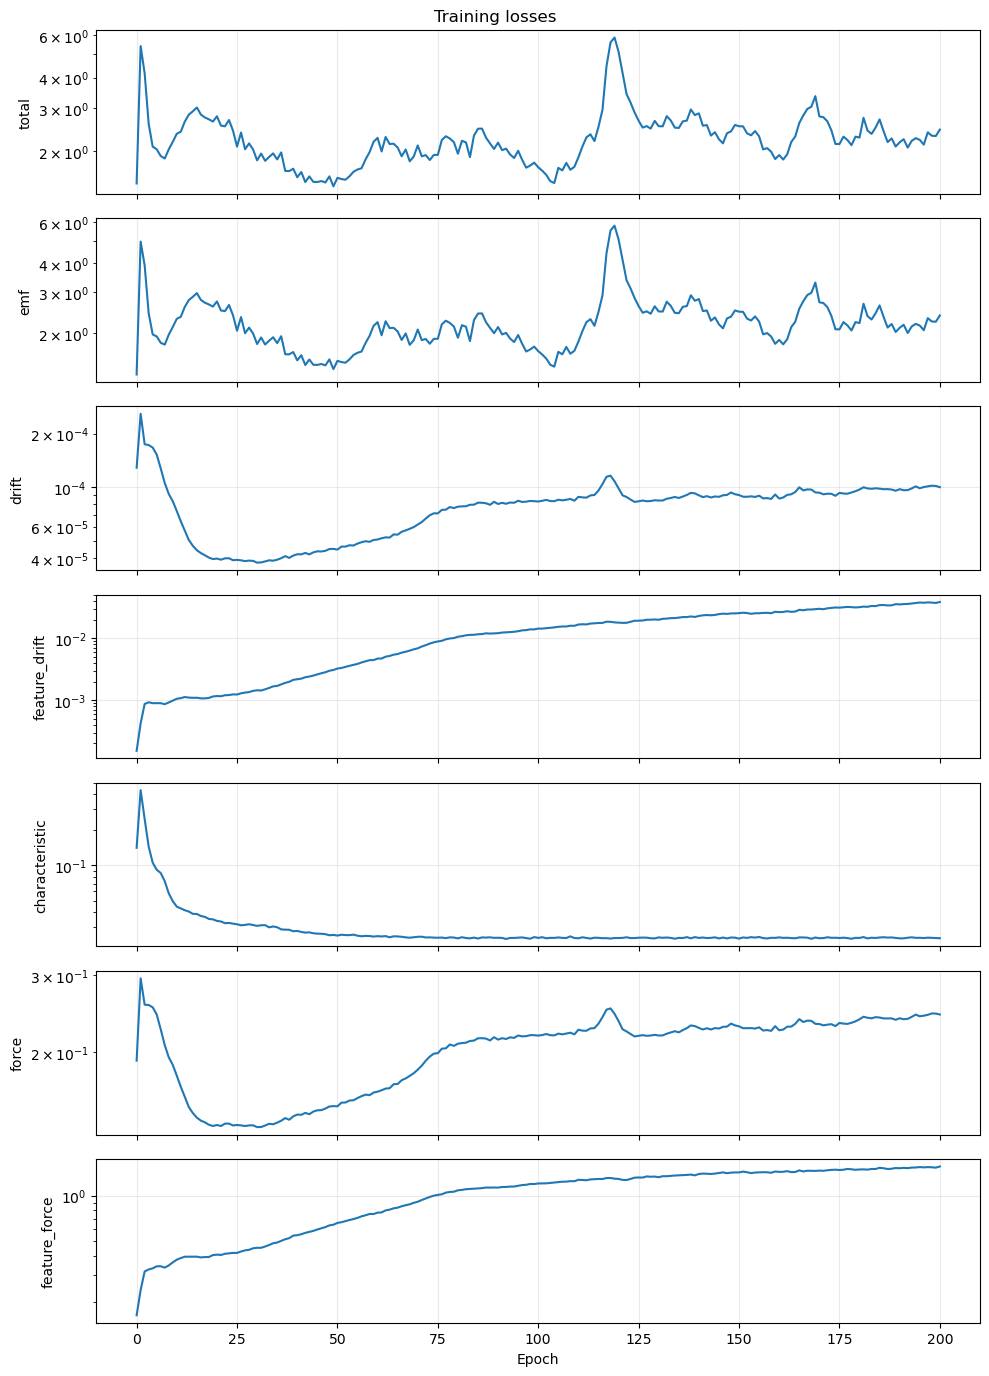

Final raw losses:
total: 2.44308979
emf: 2.38014408
drift: 0.00010003
feature_drift: 0.03879638
characteristic: 0.02404930
Final correction scales:
pixel_scale: 1.000000
feature_scale: 0.340599
characteristic_scale: 0.099408


In [14]:
joint_history = {
    "total": losses,
    "emf": emf_losses,
    "drift": drift_losses,
    "feature_drift": feature_drift_losses,
    "characteristic": characteristic_losses,
    "force": average_V,
    "feature_force": average_feature_V,
}
fig, axes = plot_loss_history(joint_history, keys=("total", "emf", "drift", "feature_drift", "characteristic", "force", "feature_force"))
plt.show()
print("Final raw losses:")
for name in ("total", "emf", "drift", "feature_drift", "characteristic"):
    print(f"{name}: {joint_history[name][-1]:.8f}")
print("Final correction scales:")
for name in ("pixel_scale", "feature_scale", "characteristic_scale"):
    print(f"{name}: {history[name][-1]:.6f}")

In [15]:
def collect_images_and_labels(data_loader):
    images, labels = [], []
    for batch_images, batch_labels in data_loader:
        images.append(batch_images.flatten(start_dim=1))
        labels.append(batch_labels)
    return torch.cat(images), torch.cat(labels)

def sample_balanced(model, n_samples, batch_size=500):
    model.eval()
    labels = torch.arange(len(SELECTED_DIGITS), dtype=torch.long)
    labels = labels.repeat((n_samples + len(labels) - 1) // len(labels))[:n_samples]
    outputs = []
    with torch.no_grad():
        for start in range(0, n_samples, batch_size):
            batch_labels = labels[start:start + batch_size].to(device)
            noise = torch.randn(batch_labels.shape[0], 784, device=device)
            outputs.append(model.generate(noise, batch_labels).cpu())
    return torch.cat(outputs), labels

real_test_images, real_test_labels = collect_images_and_labels(test_loader)
generated_images, generated_labels = sample_balanced(f_averaged, len(real_test_images))
print("Evaluation images:", real_test_images.shape, generated_images.shape)
print("Generated range before clipping:", generated_images.min().item(), generated_images.max().item())

# Fit this evaluator once and reuse its checkpoint for fair comparisons with the other algorithms.
real_train_images, real_train_labels = collect_images_and_labels(train_loader)
evaluator = fit_mnist_evaluator(real_train_images, real_train_labels, n_classes=len(SELECTED_DIGITS), feature_dim=64, epochs=5, batch_size=512, learning_rate=1e-3, device=device, random_state=1234)
evaluator.eval()
metrics = evaluate_mnist_generation(real_test_images, generated_images, evaluator=evaluator, real_labels=real_test_labels, generated_labels=generated_labels, n_classes=len(SELECTED_DIGITS), max_samples=2048)
print("Encoder-free averaged-model metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.6f}")

Evaluation images: torch.Size([6005, 784]) torch.Size([6005, 784])
Generated range before clipping: 1.286278001735205e-19 0.999639630317688
Encoder-free averaged-model metrics:
pixel_fid: 18.065537
pixel_mmd_rbf: 0.027819
pixel_sliced_wasserstein: 0.076208
requested_class_coverage: 1.000000
requested_class_entropy: 1.000000
mnist_fid: 5.404376
mnist_mmd_rbf: 0.002694
real_classifier_accuracy: 0.963863
conditional_accuracy: 0.984679
predicted_class_coverage: 1.000000
predicted_class_entropy: 0.999848
real_feature_diversity: 18.030473
generated_feature_diversity: 15.982349
feature_diversity_ratio: 0.886408
pixel_fid_class_0: 21.542067
mnist_fid_class_0: 8.136787
conditional_accuracy_class_0: 0.996004
generated_count_class_0: 1001.000000
pixel_fid_class_1: 25.855975
mnist_fid_class_1: 11.920334
conditional_accuracy_class_1: 0.989011
generated_count_class_1: 1001.000000
pixel_fid_class_2: 27.574291
mnist_fid_class_2: 15.558265
conditional_accuracy_class_2: 0.996004
generated_count_class_2:

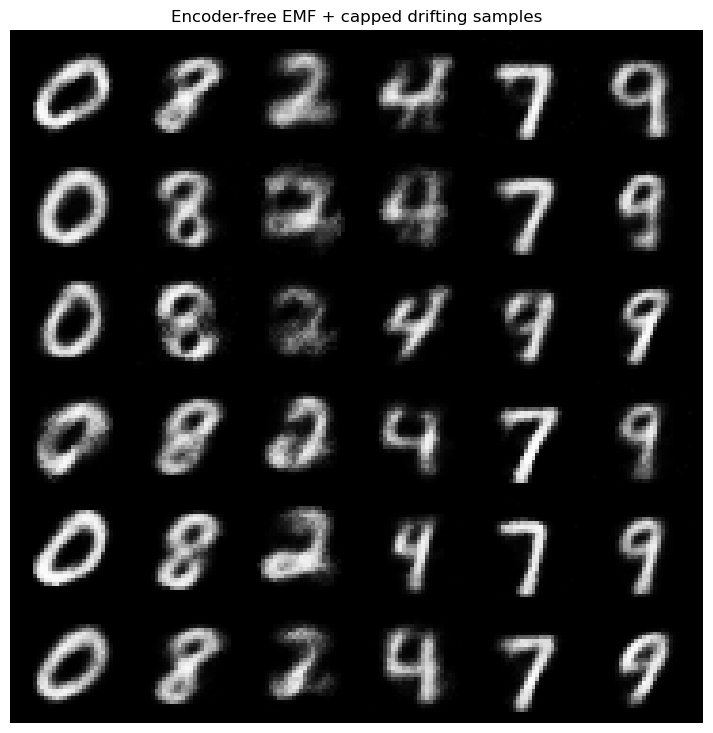

In [16]:
grid = utils.make_grid(generated_images[:36].reshape(-1, 1, 28, 28), nrow=len(SELECTED_DIGITS), padding=2, normalize=False)
plt.figure(figsize=(9, 9))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
plt.axis("off")
plt.title("Encoder-free EMF + capped drifting samples")
plt.show()